In [2]:
from pathlib import Path

audio_dir = Path('../data/raw/deam/MEMD_audio')
audio_paths = sorted(audio_dir.glob('*.mp3'))

print(f'Found {len(audio_paths)} audio files')

for path in audio_paths[:5]:
    print(path.name)

Found 1802 audio files
10.mp3
1000.mp3
1001.mp3
1002.mp3
1003.mp3


In [3]:
import soundfile as sf

path = audio_paths[0]
info = sf.info(path)

print(path.name)
print(info)

10.mp3
../data/raw/deam/MEMD_audio/10.mp3
samplerate: 44100 Hz
channels: 2
duration: 45.061 s
format: MPEG-1/2 Audio [MP3]
subtype: MPEG Layer III [MPEG_LAYER_III]


In [6]:
info.samplerate

44100

In [9]:
from collections import defaultdict

audio_data = defaultdict(list)

for i, path in enumerate(audio_paths):
    info = sf.info(path)
    audio_data['track_id'].append(int(path.stem))
    audio_data['samplerate'].append(info.samplerate)
    audio_data['channels'].append(info.channels)
    audio_data['duration_sec'].append(info.duration)
    audio_data['frames'].append(info.frames)
    audio_data['format'].append(info.format)
    audio_data['subtype'].append(info.subtype)
    audio_data['size_bytes'].append(path.stat().st_size)

In [10]:
import pandas as pd

audio_df = pd.DataFrame(audio_data)
audio_df.head()

,track_id,samplerate,channels,duration_sec,frames,format,subtype,size_bytes
0,10,44100,2,45.060998,1987190,MP3,MPEG_LAYER_III,620385
1,1000,44100,2,45.060998,1987190,MP3,MPEG_LAYER_III,622927
2,1001,44100,2,45.000023,1984501,MP3,MPEG_LAYER_III,723956
3,1002,44100,2,45.330385,1999070,MP3,MPEG_LAYER_III,723750
4,1003,44100,2,45.330385,1999070,MP3,MPEG_LAYER_III,723750


In [11]:
print(audio_df.shape)
print(audio_df['track_id'].is_unique)
print(audio_df.isna().sum())

audio_df.describe()

(1802, 8)
True
track_id        0
samplerate      0
channels        0
duration_sec    0
frames          0
format          0
subtype         0
size_bytes      0
dtype: int64


,track_id,samplerate,channels,duration_sec,frames,size_bytes
count,1802.000000,1802.000000,1802.000000,1802.000000,1.802000e+03,1.802000e+03
mean,1093.215871,44090.982242,1.992786,51.151757,2.255387e+06,7.660832e+05
std,599.658004,1190.437319,0.084653,38.462281,1.697098e+06,6.264881e+05
min,2.000000,16000.000000,1.000000,44.643039,7.200010e+05,2.736400e+05
25%,569.500000,44100.000000,2.000000,45.000023,1.984501e+06,6.122115e+05
50%,1157.500000,44100.000000,2.000000,45.034875,1.986038e+06,7.239240e+05
75%,1607.750000,44100.000000,2.000000,45.060998,1.987190e+06,7.239560e+05
max,2058.000000,48000.000000,2.000000,628.616485,2.772199e+07,1.003478e+07


In [15]:
for column in ['samplerate', 'channels', 'format', 'subtype']:
    print(f"\n{column}")
    print(audio_df[column].value_counts())


samplerate
samplerate
44100    1778
48000      20
22050       3
16000       1
Name: count, dtype: int64

channels
channels
2    1789
1      13
Name: count, dtype: int64

format
format
MP3    1802
Name: count, dtype: int64

subtype
subtype
MPEG_LAYER_III    1802
Name: count, dtype: int64


<Axes: xlabel='duration_sec', ylabel='Count'>

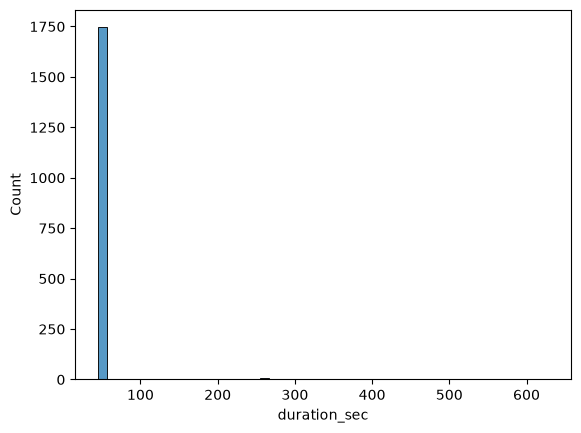

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(audio_df, x='duration_sec', bins=50)